In [1]:
import pandas as pd
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.lines import Line2D
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import BoundaryNorm, ListedColormap
import warnings
warnings.filterwarnings('ignore')
unibern = "#8a1e22"

In [2]:
# ── 1. Load 20CRv3 ──────────────────────────────────────────────────────────

def load_20cr(year):
    ds = nc.Dataset(f'/scratch2/ccorbella/files/20CRv3_misc/TMP2m_daymean_Europe/anl_mean_{year}_TMP_2m_daymean_Europe.nc')
    t = ds.variables['time']
    times = nc.num2date(t[:], t.units, calendar=getattr(t,'calendar','standard'))
    dates = pd.to_datetime([str(tt)[:10] for tt in times])
    lat = ds.variables['latitude'][:]
    lon = ds.variables['longitude'][:]
    t2m = ds.variables['t2m'][:] - 273.15
    ds.close()
    return dates, lat, lon, t2m

dates_29, lat, lon, t2m_29 = load_20cr(1829)
dates_30, _, _, t2m_30 = load_20cr(1830)
all_dates = np.concatenate([dates_29, dates_30])
all_t2m = np.concatenate([t2m_29, t2m_30], axis=0)

def extract_20cr(station_lat, station_lon):
    ilat = np.argmin(np.abs(lat - station_lat))
    ilon = np.argmin(np.abs(lon - station_lon))
    ts = pd.Series(all_t2m[:, ilat, ilon], index=all_dates, name='t2m_20cr')
    return ts


In [3]:
# ── 2. Load stations ─────────────────────────────────────────────────────────

station_files = {
    'Padua':    ('/scratch3/PALAEO-RA/daily_data/final/Padua/IMPROVE_Padua_17250112-19970531_ta_daily_qc.tsv', 45.4, 11.87),
    'Milan':    ('/scratch3/PALAEO-RA/daily_data/final/Milan/Maugeri-et-al_Milan_17630101-19491231_ta_daily_qc.tsv', 45.47, 9.19),
    'Bologna':  ('/scratch3/PALAEO-RA/daily_data/final/Bologna/ECA&D_Bologna_18140101-20031231_ta_daily_qc.tsv', 44.5, 11.345833),
    'Turin':    ('/scratch3/PALAEO-RA/daily_data/final/Turin/SMI_Turin_17530101-18651130_ta_subdaily_qc.tsv', 45.068, 7.684),
    'Rovereto': ('/scratch3/PALAEO-RA/daily_data/final/Rovereto/PALAEO-RA_Rovereto_Bonfioli_17820214-18390827_ta_subdaily_qc.tsv', 45.9, 11.05),
}
# colors_sta = {'Padua': '#1f77b4', 'Milan': '#d62728', 'Turin': '#2ca02c', 'Rovereto': '#ff7f0e',
#               'Bologna': '#9467bd'}
colors_sta = {'Padua': '#1f77b4', 'Milan': '#d62728', 'Turin': '#2ca02c', 'Rovereto': '#ff7f0e',
              'Bologna': '#9467bd'}

def parse_sef(filepath):
    header_line = None
    with open(filepath, 'r', encoding='utf-8', errors='replace') as f:
        for i, line in enumerate(f):
            if line.strip().startswith('Year'):
                header_line = i
                break
    df = pd.read_csv(filepath, sep='\t', skiprows=header_line, na_values=['NA'],
                     encoding='utf-8', encoding_errors='replace')
    df['date'] = pd.to_datetime(
        df[['Year','Month','Day']].rename(columns={'Year':'year','Month':'month','Day':'day'}),
        errors='coerce')
    df['Value'] = pd.to_numeric(df['Value'], errors='coerce')
    df = df.dropna(subset=['date','Value'])
    daily = df.groupby('date')['Value'].mean().reset_index()
    daily.columns = ['date', 'ta']
    daily = daily.set_index('date').sort_index()
    return daily

In [4]:
# ── 3. Compute anomalies ─────────────────────────────────────────────────────

winter_start = '1829-11-01'
winter_end   = '1830-02-28'

stations = {}
for name, (fp, slat, slon) in station_files.items():
    daily = parse_sef(fp)
    cr = extract_20cr(slat, slon)
    
    obs_w = daily.loc[winter_start:winter_end]['ta']
    cr_w  = cr.loc[winter_start:winter_end]
    common = obs_w.index.intersection(cr_w.index)
    obs_c = obs_w.loc[common]
    cr_c  = cr_w.loc[common]
    
    obs_mean = obs_c.mean()
    cr_mean  = cr_c.mean()
    
    stations[name] = {
        'daily': daily,           # ← ADD THIS LINE
        'lat': slat, 'lon': slon, # ← ADD THIS LINE
        'obs_abs': obs_c,
        'cr_abs': cr_c,
        'obs_anom': obs_c - obs_mean,
        'cr_anom': cr_c - cr_mean,
        'obs_mean': obs_mean,
        'cr_mean': cr_mean,
    }

In [5]:
# Figure Style
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.6,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
})

# High-contrast, colorblind-friendly palette
palette = ['#0077BB', '#EE7733', '#AA3377', '#009988', '#CC3311']
#           Padua      Milan      Bologna    Turin      Rovereto
colors_sta = {name: palette[i] for i, name in enumerate(stations)}

In [6]:
# ── Build station_coords and pairs_df for panel (d) ──────────────────────────
from itertools import combinations

# Station coordinates (lat, lon, alt) — alt read from SEF headers
station_coords = {
    'Padua':    (45.4,    11.87,   18),
    'Milan':    (45.47,    9.19,  150),
    'Bologna':  (44.50,   11.35,   74),
    'Turin':    (45.068,   7.684, 282),
    'Rovereto': (45.9,    11.05,  200),
}

def to_monthly_anom(daily_df):
    monthly = daily_df.resample('MS').agg(['mean', 'count'])
    monthly.columns = ['ta', 'count']
    monthly.loc[monthly['count'] < 20, 'ta'] = np.nan
    monthly = monthly[['ta']].dropna()
    monthly['month'] = monthly.index.month
    clim = monthly.groupby('month')['ta'].mean()
    monthly['anom'] = monthly['ta'] - monthly['month'].map(clim)
    return monthly[['ta', 'anom']]

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat, dlon = np.radians(lat2 - lat1), np.radians(lon2 - lon1)
    a = (np.sin(dlat/2)**2
         + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2))
         * np.sin(dlon/2)**2)
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

# Compute monthly anomalies from the full daily records
full_monthly = {}
for name in station_coords:
    if name in stations:
        full_monthly[name] = to_monthly_anom(stations[name]['daily'])

# Pairwise correlations
pair_results = []
for (n1, c1), (n2, c2) in combinations(station_coords.items(), 2):
    if n1 not in full_monthly or n2 not in full_monthly:
        continue
    lat1, lon1, _ = c1
    lat2, lon2, _ = c2
    m1, m2 = full_monthly[n1], full_monthly[n2]
    merged = (m1[['anom']]
              .join(m2[['anom']], lsuffix='_1', rsuffix='_2', how='inner')
              .dropna())
    if len(merged) < 24:
        continue
    pair_results.append({
        'station1': n1, 'station2': n2,
        'dist_km': haversine(lat1, lon1, lat2, lon2),
        'corr': merged['anom_1'].corr(merged['anom_2']),
        'lat1': lat1, 'lon1': lon1, 'lat2': lat2, 'lon2': lon2,
    })
pairs_df = pd.DataFrame(pair_results)

✓ Saved


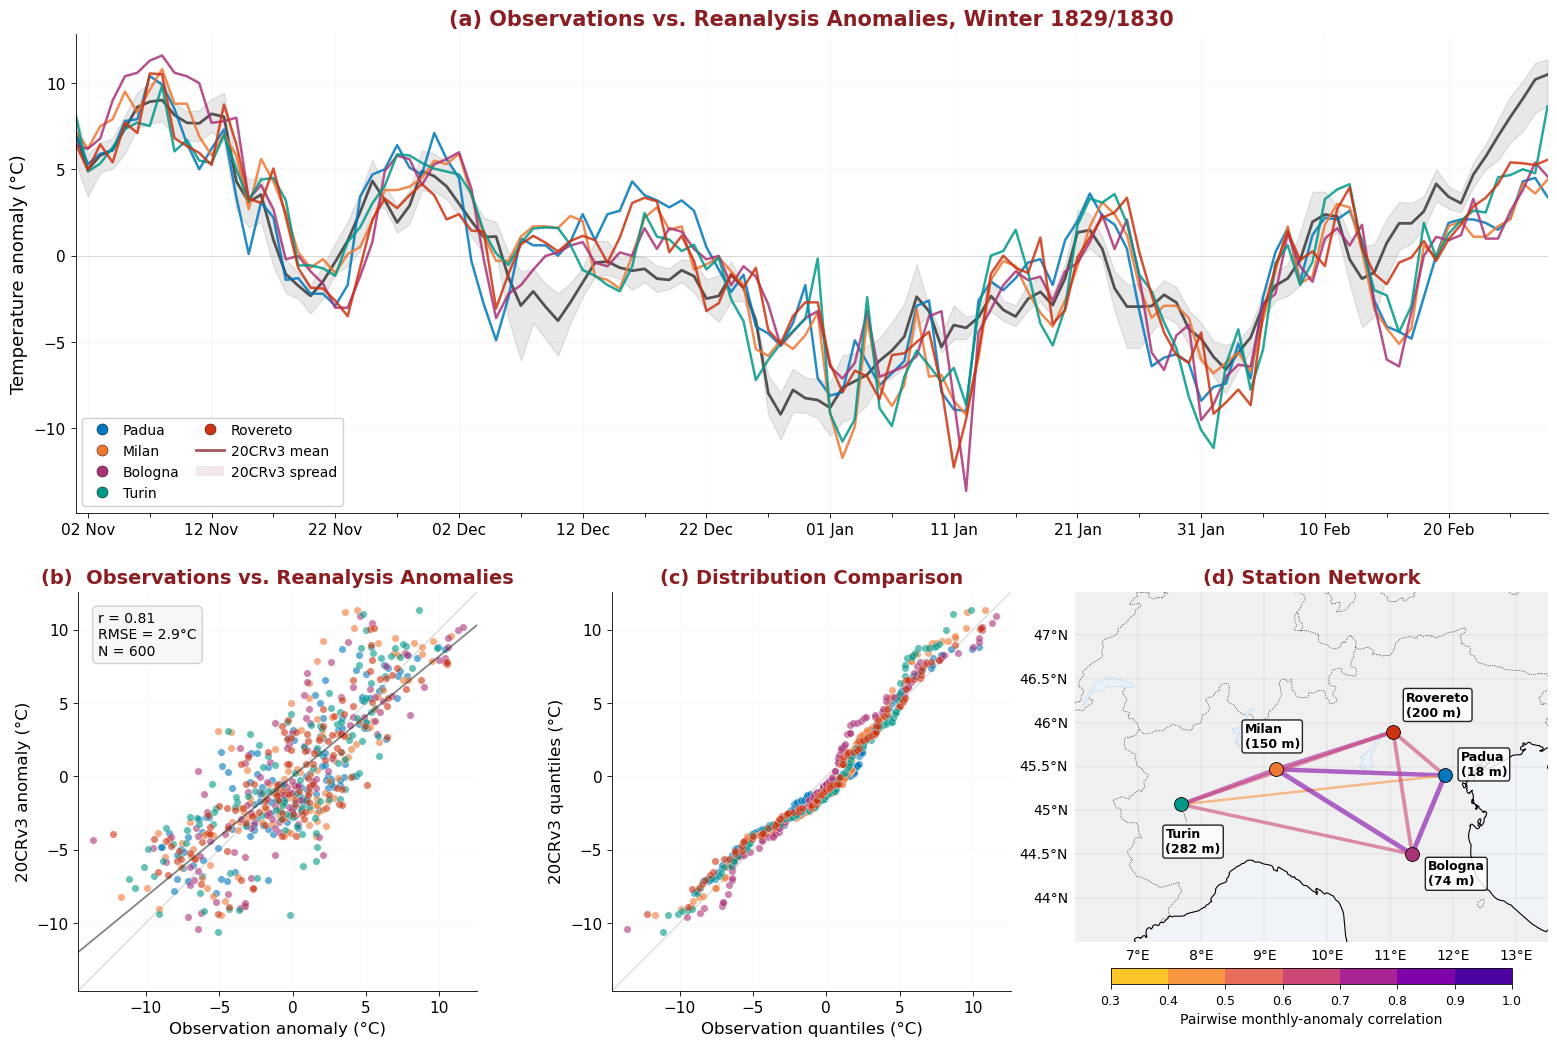

In [7]:
# ── 4. Figure ────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(16, 11))
gs = fig.add_gridspec(2, 3, hspace=0.18, wspace=0.32, height_ratios=[1.2, 1],
                      left=0.06, right=0.98, top=0.95, bottom=0.08)

# --- Panel (a): Time series of anomalies ---
ax_ts = fig.add_subplot(gs[0, :])

for name, s in stations.items():
    ax_ts.plot(s['obs_anom'].index, s['obs_anom'].values, '-', 
               color=colors_sta[name], linewidth=1.8, alpha=0.85, label=f'{name} obs')

# 20CRv3: average the anomalies from all 4 grid cells for a single reference line
# 20CRv3 envelope (min/max shading) + mean line
cr_anoms_all = pd.DataFrame({n: s['cr_anom'] for n, s in stations.items()})
cr_mean_anom = cr_anoms_all.mean(axis=1)
cr_min = cr_anoms_all.min(axis=1)
cr_max = cr_anoms_all.max(axis=1)

ax_ts.fill_between(cr_mean_anom.index, cr_min.values, cr_max.values,
                    color="#241f1f", alpha=0.10, label='20CRv3 spread (4 cells)', zorder=0)
ax_ts.plot(cr_mean_anom.index, cr_mean_anom.values, '-', color="#241f1f", linewidth=2,
           alpha=0.75, label='20CRv3 mean', zorder=1)
ax_ts.set_xlim([cr_mean_anom.index[0], cr_mean_anom.index[-1]])
ax_ts.axhline(0, color='k', ls='-', alpha=0.15, lw=0.5)
ax_ts.set_ylabel('Temperature anomaly (°C)', fontsize=13)
ax_ts.set_title('(a) Observations vs. Reanalysis Anomalies, Winter 1829/1830',
                fontsize=15, fontweight='semibold', color=unibern)
# ax_ts.legend(fontsize=9, ncol=4, loc='upper center', bbox_to_anchor=(0.5, -0.08),
#              frameon=False, columnspacing=1.5)
ax_ts.grid(True, alpha=0.15, lw=0.5)

leg_handles = []
for name in stations:
    leg_handles.append(Line2D([0], [0], marker='o', color='w',
                              markerfacecolor=colors_sta[name], markersize=8,
                              markeredgecolor='k', markeredgewidth=0.3,
                              label=name, linestyle='None'))
leg_handles.append(Line2D([0], [0], color=unibern, lw=2, alpha=0.75, label='20CRv3 mean'))
leg_handles.append(plt.Rectangle((0, 0), 1, 1, fc=unibern, alpha=0.10,
                                  edgecolor='none', label='20CRv3 spread'))

ax_ts.legend(handles=leg_handles, fontsize=10, loc='lower left',
             ncol=2, framealpha=0.92, edgecolor='#cccccc',
             columnspacing=1.2, handletextpad=0.5)


# Replace the x-axis formatting block with:
ax_ts.xaxis.set_major_locator(mdates.DayLocator(interval=10))
ax_ts.xaxis.set_minor_locator(mdates.DayLocator(interval=5))
ax_ts.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax_ts.tick_params(axis='x', which='minor', length=3)

# --- Pool all station anomalies for scatter and QQ ---
all_obs_anom = []
all_cr_anom = []
for name, s in stations.items():
    all_obs_anom.append(s['obs_anom'].values)
    all_cr_anom.append(s['cr_anom'].values)

all_obs = np.concatenate(all_obs_anom)
all_cr  = np.concatenate(all_cr_anom)

r_val = np.corrcoef(all_obs, all_cr)[0, 1]
rmse  = np.sqrt(np.mean((all_obs - all_cr)**2))
lims = [min(all_obs.min(), all_cr.min()) - 1, max(all_obs.max(), all_cr.max()) + 1]

# --- Panel (b): Scatter plot ---
ax_sc = fig.add_subplot(gs[1, 0])

for name, s in stations.items():
    ax_sc.scatter(s['obs_anom'], s['cr_anom'], s=28, alpha=0.6, 
                  color=colors_sta[name], edgecolor='white', linewidth=0.3, label=name)

ax_sc.plot(lims, lims, '-', color='#aaaaaa', alpha=0.5, lw=0.8, zorder=0)

# Regression line
slope, intercept = np.polyfit(all_obs, all_cr, 1)
xfit = np.linspace(lims[0], lims[1], 50)
ax_sc.plot(xfit, slope*xfit + intercept, '-', color='#333333', alpha=0.6, lw=1.3)

ax_sc.set_xlim(lims); ax_sc.set_ylim(lims)
ax_sc.set_aspect('equal')
ax_sc.set_xlabel('Observation anomaly (°C)', fontsize=12)
ax_sc.set_ylabel('20CRv3 anomaly (°C)', fontsize=12)
ax_sc.set_title('(b)  Observations vs. Reanalysis Anomalies',
                color=unibern, fontsize=14, fontweight='semibold')
ax_sc.text(0.05, 0.95,
           f'r = {r_val:.2f}\nRMSE = {rmse:.1f}°C\nN = {len(all_obs)}',
           transform=ax_sc.transAxes, fontsize=10, va='top',
           bbox=dict(boxstyle='round,pad=0.4', facecolor='#f7f7f7',
                     edgecolor='#cccccc', alpha=0.9))
ax_sc.grid(True, alpha=0.1, lw=0.5)

# --- Panel (c): Q-Q plot ---
ax_qq = fig.add_subplot(gs[1, 1])

for name, s in stations.items():
    obs_q = np.sort(s['obs_anom'].values)
    cr_q = np.sort(s['cr_anom'].values)
    ax_qq.scatter(obs_q, cr_q, s=28, alpha=0.6, color=colors_sta[name],
                  edgecolor='white', linewidth=0.3, label=name)
ax_qq.plot(lims, lims, '-', color='#aaaaaa', alpha=0.5, lw=0.8, zorder=0)
ax_qq.set_xlim(lims); ax_qq.set_ylim(lims)
ax_qq.set_aspect('equal')
ax_qq.set_xlabel('Observation quantiles (°C)', fontsize=12)
ax_qq.set_ylabel('20CRv3 quantiles (°C)', fontsize=12)
ax_qq.set_title('(c) Distribution Comparison', fontsize=14, 
                color=unibern, fontweight='semibold')
ax_qq.grid(True, alpha=0.1, lw=0.5)

# --- Panel (d): Station map ---

# Get the bounding box of panels (b) and (c) to align panel (d)
fig.canvas.draw()
bb_sc = ax_sc.get_position()
bb_qq = ax_qq.get_position()

# Panel (d): left edge close to panel (c), bottom aligned with (b)/(c), top near their top
map_left = bb_qq.x1 + 0.04
map_bottom = bb_sc.y0- 0.04
map_width = 0.98 - map_left
map_height = (bb_sc.y1 - bb_sc.y0) * 1.11

ax_map = fig.add_axes([map_left, map_bottom, map_width, map_height],
                       projection=ccrs.PlateCarree())
ax_map.set_extent([6.0, 13.5, 43.5, 47.5], crs=ccrs.PlateCarree())
ax_map.set_aspect('auto')

# Remove the black frame/border around the map
for spine in ax_map.spines.values():
    spine.set_visible(False)
ax_map.outline_patch.set_visible(False) if hasattr(ax_map, 'outline_patch') else None

# Background
ax_map.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax_map.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=':')
ax_map.add_feature(cfeature.LAND, facecolor='#f0f0f0', edgecolor='none', zorder=0)
ax_map.add_feature(cfeature.OCEAN, facecolor='#f0f4f8', zorder=0)
ax_map.add_feature(cfeature.LAKES, facecolor='#e8f0f8', edgecolor='#aaccee', linewidth=0.3)

# Discrete colormap for pairwise correlation lines
boundaries = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
discrete_colors = sns.color_palette("plasma", 7)[::-1]  # Reverse to have darker colors for higher correlations

cmap_disc = ListedColormap(discrete_colors)
norm_disc = BoundaryNorm(boundaries, cmap_disc.N)

for _, r in pairs_df.iterrows():
    color = cmap_disc(norm_disc(r['corr']))
    lw = max(1.5, 4 * r['corr'])
    ax_map.plot([r['lon1'], r['lon2']], [r['lat1'], r['lat2']],
                color=color, linewidth=lw, alpha=0.6, zorder=2,
                transform=ccrs.PlateCarree())

# Station dots + labels — Turin label moved south
label_offsets = {
    'Padua': (0.25, 0), 'Milan': (-.5, 0.25), 'Bologna': (0.25, -0.35),
    'Turin': (-0.25, -0.55), 'Rovereto': (0.2, 0.18),
}
for name, (slat, slon, alt) in station_coords.items():
    c = colors_sta.get(name, 'gray')
    ax_map.plot(slon, slat, 'o', color=c, markersize=10,
                markeredgecolor='k', markeredgewidth=0.6, zorder=5,
                transform=ccrs.PlateCarree())
    dx, dy = label_offsets.get(name, (0.2, 0.15))
    ax_map.annotate(f"{name}\n({alt} m)", xy=(slon, slat),
                    xytext=(slon + dx, slat + dy),
                    fontsize=9, fontweight='bold', zorder=6,
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.85),
                    arrowprops=dict(arrowstyle='-', color='gray', lw=0.5)
                    if abs(dx) > 1 or abs(dy) > 0.4 else None,
                    transform=ccrs.PlateCarree())

# Discrete colorbar beneath the map
sm = plt.cm.ScalarMappable(cmap=cmap_disc, norm=norm_disc)
sm.set_array([])
cb = plt.colorbar(sm, ax=ax_map, orientation='horizontal', pad=0.06, shrink=0.85, aspect=25,
                  ticks=boundaries, spacing='uniform')
cb.set_label('Pairwise monthly-anomaly correlation', fontsize=10)
cb.ax.tick_params(labelsize=7)

gl = ax_map.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.3)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size':10}
gl.ylabel_style = {'size': 10}
cb.ax.tick_params(labelsize=9)
ax_map.set_title('(d) Station Network', fontsize=14, 
                 color=unibern,fontweight='semibold')

###################### save fig #####################################

plt.savefig('image/validation_anomalies_combined.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('image/validation_anomalies_combined.pdf', bbox_inches='tight', facecolor='white')
print("✓ Saved")


Panel (b) is a scatter plot of observed vs. reanalysis daily anomalies. Each dot is one station-day. If the reanalysis perfectly reproduced observations, all points would sit on the 1:1 diagonal. The spread around that line shows disagreement. The regression line tells you about systematic bias — if it's shallower than 1:1, the reanalysis underestimates variability. Your r=0.81 and RMSE=2.9°C indicate good but not perfect agreement, which is reasonable for a ~200-year-old reanalysis product.


Panel (c) is a quantile-quantile plot — it compares the distributions rather than day-by-day correspondence. The sorted observed values are plotted against sorted reanalysis values. Points on the diagonal mean both distributions have the same shape. Departures at the tails (which you can see — the upper-right dots drift above the line) mean the reanalysis overestimates extreme warm anomalies relative to observations, or underestimates extreme cold ones. It's complementary to (b): the scatter shows temporal agreement, the Q-Q shows distributional agreement.

In [8]:
print(f"\n=== POOLED ANOMALY STATS ===")
print(f"  r = {r_val:.3f}")
print(f"  RMSE = {rmse:.2f}°C")
print(f"  N = {len(all_obs)} days (4 stations × 120)")

# Per-station anomaly stats
print(f"\n=== PER-STATION ANOMALY STATS ===")
for name, s in stations.items():
    o, c = s['obs_anom'].values, s['cr_anom'].values
    r = np.corrcoef(o, c)[0,1]
    rmse_s = np.sqrt(np.mean((o-c)**2))
    bias_s = np.mean(c - o)
    print(f"  {name:12s}: r={r:.3f}  RMSE={rmse_s:.2f}°C  bias={bias_s:+.2f}°C")


=== POOLED ANOMALY STATS ===
  r = 0.810
  RMSE = 2.90°C
  N = 600 days (4 stations × 120)

=== PER-STATION ANOMALY STATS ===
  Padua       : r=0.843  RMSE=2.49°C  bias=-0.00°C
  Milan       : r=0.803  RMSE=3.03°C  bias=-0.00°C
  Bologna     : r=0.821  RMSE=2.98°C  bias=+0.00°C
  Turin       : r=0.781  RMSE=3.24°C  bias=+0.00°C
  Rovereto    : r=0.809  RMSE=2.70°C  bias=+0.00°C


# Monthly Mean of the Winter 1829/1830

In [22]:
def read_sef(filepath):
    with open(filepath, 'r') as f:
        lines = f.readlines()
    for i, line in enumerate(lines):
        if line.startswith('Year'):
            header_idx = i
            break
    df = pd.read_csv(filepath, sep='\t', skiprows=header_idx, na_values='NA')
    df['Value'] = pd.to_numeric(df['Value'], errors='coerce')
    # Handle Day=NA (monthly-only rows) by skipping them
    df = df.dropna(subset=['Day'])
    df['Day'] = df['Day'].astype(int)
    df['date'] = pd.to_datetime(
        df[['Year', 'Month', 'Day']].rename(
            columns={'Year': 'year', 'Month': 'month', 'Day': 'day'}
        )
    )
    # Aggregate to daily means (handles subdaily files)
    df = df.groupby('date').agg({'Value': 'mean'}).reset_index()
    return df


In [23]:

# --- Load and filter to winter 1829/30 ---
winter_start = '1828-11-01'
winter_end = '1833-03-31'


stations = {}
for name, (path, lat, lon) in station_files.items():
    df = read_sef(path)
    mask = (df['date'] >= winter_start) & (df['date'] <= winter_end)
    w = df.loc[mask].copy()
    if len(w) > 0:
        stations[name] = w
    else:
        print(f"Warning: {name} has no data for winter 1829/30")

w = stations['Padua']

monthly = w.groupby(w['date'].dt.to_period('M')).agg(
    mean_val=('Value', 'mean'),
    first_day=('date', 'first'),
    last_day=('date', 'last')
).reset_index(drop=True)

mask = ((df['date'] >= winter_start) & (df['date'] <= winter_end))
winter = df.loc[mask].copy()



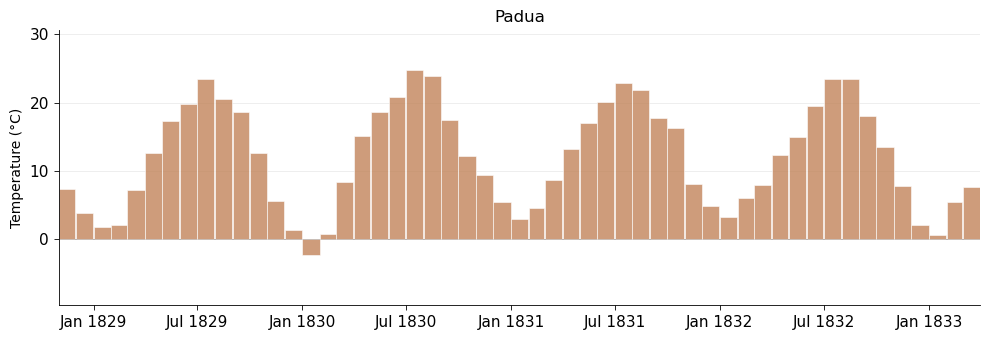

In [24]:
fig, ax = plt.subplots(figsize=(10, 3.5))

for _, row in monthly.iterrows():
    ax.bar(row['first_day'] + (row['last_day'] - row['first_day']) / 2,
           row['mean_val'],
           width=row['last_day'] - row['first_day'],
           color='#c2845a', alpha=0.8, edgecolor='white', linewidth=0.5)

ax.set_ylabel('Temperature (°C)')
ax.set_xlim(w['date'].min(), w['date'].max())
ax.set_ylim(w['Value'].min() - 2, w['Value'].max() + 2)  # fix ylim across all 4
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.axhline(0, color='k', linewidth=0.5, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linewidth=0.5)
ax.set_axisbelow(True)  # grid behind the bars
ax.set_title('Padua')
plt.tight_layout()
plt.savefig('image/winter_1829_daily_vs_monthly_1.pdf')
plt.savefig('image/winter_1829_daily_vs_monthly_1.svg')


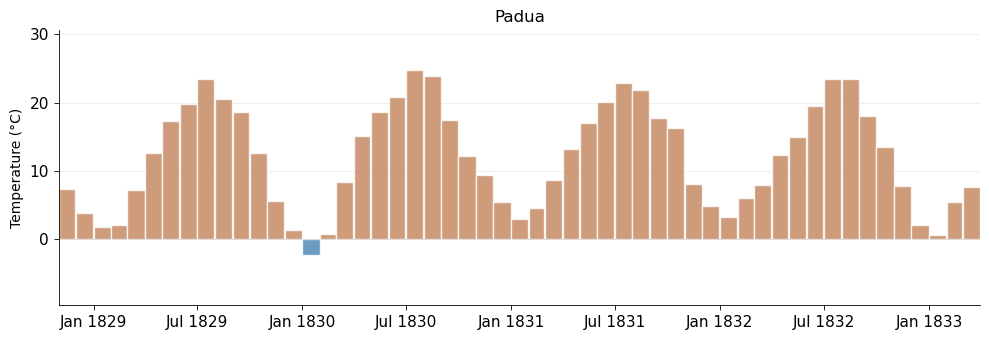

In [25]:
fig, ax = plt.subplots(figsize=(10, 3.5))

for _, row in monthly.iterrows():
    c = 'steelblue' if row['mean_val'] < 0 else '#c2845a'
    ax.bar(row['first_day'] + (row['last_day'] - row['first_day']) / 2,
           row['mean_val'],
           width=row['last_day'] - row['first_day'],
           color=c, alpha=0.8, edgecolor='white')

ax.axhline(0, color='k', linewidth=0.5, zorder=0)
ax.set_ylabel('Temperature (°C)')
ax.set_xlim(w['date'].min(), w['date'].max())
ax.set_ylim(w['Value'].min() - 2, w['Value'].max() + 2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linewidth=0.5)
ax.set_axisbelow(True)  # grid behind the bars
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.axhline(0, color='k', linewidth=0.5, zorder=0)
ax.set_title('Padua')

plt.tight_layout()
plt.savefig('image/winter_1829_daily_vs_monthly_2.svg')
plt.savefig('image/winter_1829_daily_vs_monthly_2.pdf')


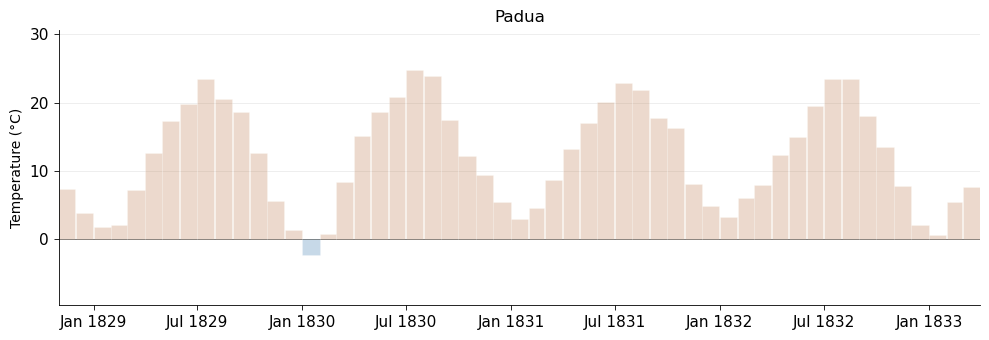

In [28]:
fig, ax = plt.subplots(figsize=(10, 3.5))

for _, row in monthly.iterrows():
    c = 'steelblue' if row['mean_val'] < 0 else '#c2845a'
    ax.bar(row['first_day'] + (row['last_day'] - row['first_day']) / 2,
           row['mean_val'],
           width=row['last_day'] - row['first_day'],
           color=c, alpha=0.3, edgecolor='white', linewidth=0.5)

ax.axhline(0, color='k', linewidth=0.5, zorder=0)
ax.plot(w['date'], w['Value'], color='k', linewidth=0.8, label='Daily')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linewidth=0.5)
ax.set_axisbelow(True)  # grid behind the bars
ax.set_ylabel('Temperature (°C)')
ax.set_xlim(w['date'].min(), w['date'].max())
ax.set_ylim(w['Value'].min() - 2, w['Value'].max() + 2)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.set_title('Padua')
plt.tight_layout()
plt.savefig('image/winter_1829_daily_vs_monthly_3.pdf')
plt.savefig('image/winter_1829_daily_vs_monthly_3.svg')



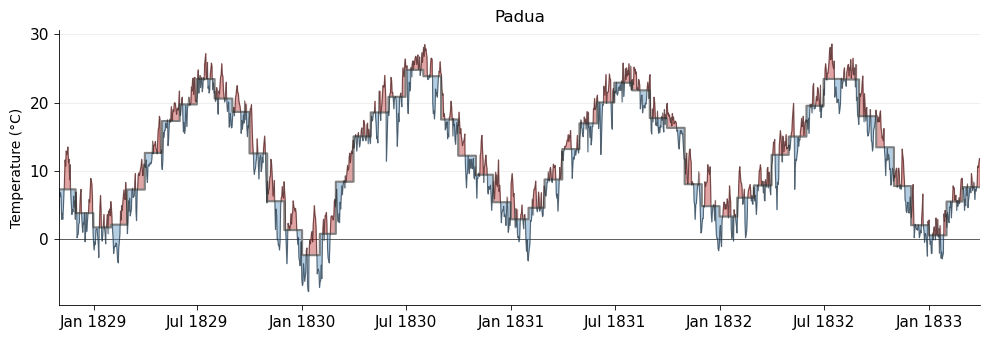

In [27]:
fig, ax = plt.subplots(figsize=(10, 3.5))

# Assign each day its monthly mean
w = w.copy()
w['monthly_mean'] = w['date'].dt.to_period('M').map(
    monthly.set_index(monthly['first_day'].dt.to_period('M'))['mean_val']
)

# Shade the gap
ax.fill_between(w['date'], w['monthly_mean'], w['Value'],
                where=(w['Value'] >= w['monthly_mean']),
                color='firebrick', alpha=0.4, label='Warmer than monthly mean')
ax.fill_between(w['date'], w['monthly_mean'], w['Value'],
                where=(w['Value'] < w['monthly_mean']),
                color='steelblue', alpha=0.4, label='Colder than monthly mean')

# Monthly step + daily line
ax.plot(w['date'], w['monthly_mean'], color='grey', linewidth=1.5,
        drawstyle='steps-mid', label='Monthly mean')
ax.plot(w['date'], w['Value'], color='k', linewidth=0.7, alpha=0.5, label='Daily')

ax.axhline(0, color='k', linewidth=0.5, zorder=0)
ax.set_ylabel('Temperature (°C)')
ax.set_xlim(w['date'].min(), w['date'].max())
ax.set_ylim(w['Value'].min() - 2, w['Value'].max() + 2)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linewidth=0.5)
ax.set_axisbelow(True)  # grid behind the bars
ax.set_title('Padua')
plt.tight_layout()
plt.savefig('image/winter_1829_daily_vs_monthly_4.pdf')
plt.savefig('image/winter_1829_daily_vs_monthly_4.svg')


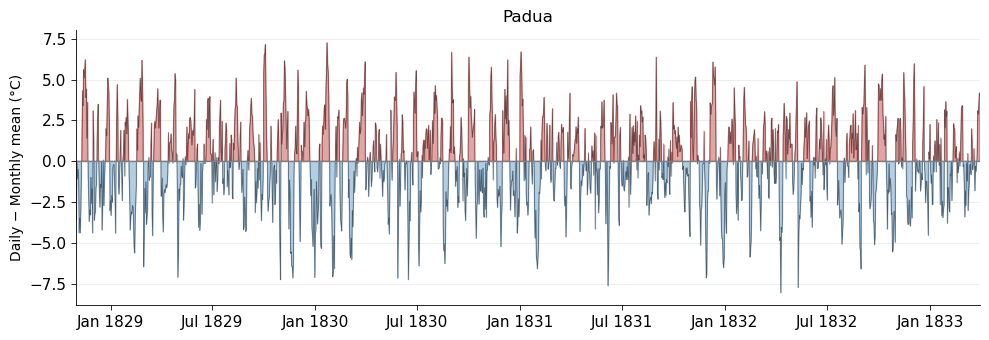

In [19]:
w['anomaly'] = w['Value'] - w['monthly_mean']

fig, ax = plt.subplots(figsize=(10, 3.5))

ax.fill_between(w['date'], 0, w['anomaly'],
                where=(w['anomaly'] >= 0),
                color='firebrick', alpha=0.4)
ax.fill_between(w['date'], 0, w['anomaly'],
                where=(w['anomaly'] < 0),
                color='steelblue', alpha=0.4)

ax.plot(w['date'], w['anomaly'], color='k', linewidth=0.5, alpha=0.5)
ax.axhline(0, color='grey', linewidth=1)

ax.set_ylabel('Daily − Monthly mean (°C)')
ax.set_xlim(w['date'].min(), w['date'].max())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linewidth=0.5)
ax.set_axisbelow(True)
ax.set_title('Padua')
plt.tight_layout()
plt.savefig('image/winter_1829_daily_vs_monthly_5.png', dpi=200)

The plot looks regular because by construction, daily departures from their own monthly mean are always bounded — every month gets recentered to zero, so you're only seeing intra-monthly variability. The seasonal cycle is gone, and so is the actual severity of winter 1829/30, because that month's mean was already very cold. The extreme event gets "absorbed" into the baseline.
So this plot honestly doesn't serve your purpose well. It answers "how noisy are daily data within a month?" (answer: consistently ±4–6°C), but it doesn't answer "what do you miss without daily data?".

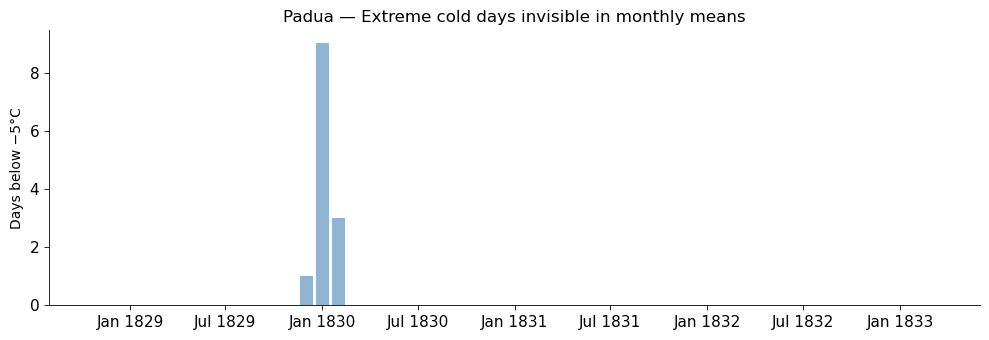

In [20]:
w['below_threshold'] = w['Value'] < -5
frost_days = w.groupby(w['date'].dt.to_period('M'))['below_threshold'].sum()

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(frost_days.index.to_timestamp(), frost_days.values,
       width=25, color='steelblue', alpha=0.6)
ax.set_ylabel('Days below −5°C')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.set_title('Padua — Extreme cold days invisible in monthly means')
plt.tight_layout()

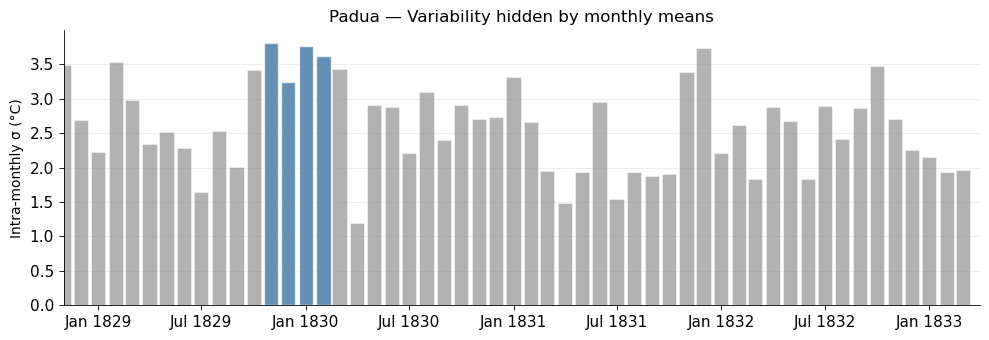

In [21]:
monthly_std = w.groupby(w['date'].dt.to_period('M'))['Value'].std()

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(monthly_std.index.to_timestamp(), monthly_std.values,
       width=25, color='grey', alpha=0.6, edgecolor='white', linewidth=0.5)

# After the bar plot, highlight the winter months
for p in monthly_std.index:
    if (p.year == 1829 and p.month >= 11) or (p.year == 1830 and p.month <= 2):
        ax.bar(p.to_timestamp(), monthly_std[p],
               width=25, color='steelblue', alpha=0.7, edgecolor='white')
        
ax.set_ylabel('Intra-monthly σ (°C)')
ax.set_xlim(w['date'].min(), w['date'].max())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linewidth=0.5)
ax.set_axisbelow(True)
ax.set_title('Padua — Variability hidden by monthly means')
plt.tight_layout()